In [1]:
import pandas as pd

url = r'D:\OneDrive\Desktop\recc.xlsx'

df = pd.read_excel(url)

df["text"] = (
    df["Title"].fillna("") + " " +
    df["Abstract"].fillna("")
).str.lower()


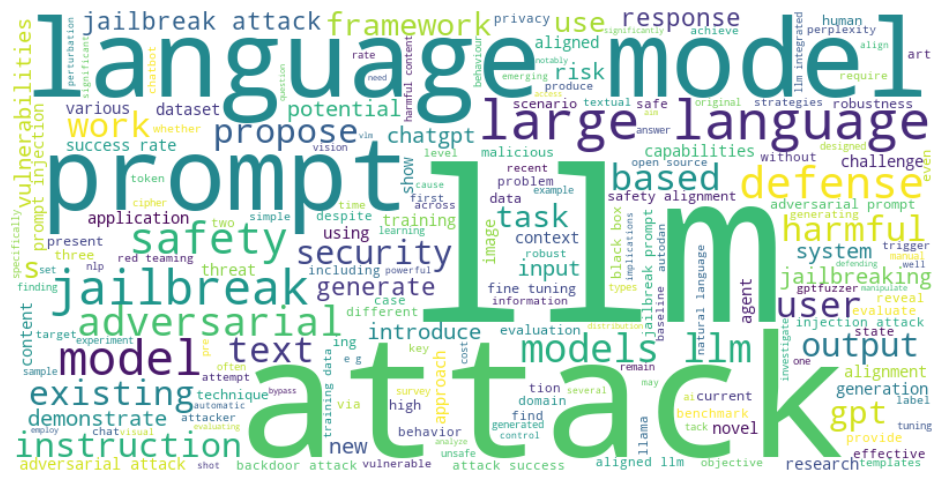

In [ ]:
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# basic cleaning
def clean(t):
    t = re.sub(r"[^a-z0-9 ]", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

df["clean_text"] = df["text"].apply(clean)

stopwords = set(STOPWORDS)
stopwords.update(["study", "paper", "result", "results", "method", "methods"])

all_text = " ".join(df["clean_text"].tolist())

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords,
    max_words=200
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


In [3]:
from collections import Counter

word_counts = Counter(all_text.split())
top_50 = word_counts.most_common(50)
print(top_50)


[('the', 508), ('and', 342), ('to', 339), ('of', 313), ('a', 220), ('we', 195), ('in', 187), ('llms', 172), ('that', 148), ('models', 127), ('attacks', 120), ('language', 110), ('with', 109), ('for', 106), ('on', 99), ('llm', 93), ('jailbreak', 87), ('as', 85), ('adversarial', 84), ('can', 82), ('attack', 81), ('our', 78), ('large', 76), ('this', 75), ('prompts', 72), ('safety', 68), ('is', 68), ('prompt', 67), ('by', 65), ('an', 64), ('model', 63), ('are', 62), ('these', 57), ('be', 50), ('from', 50), ('such', 47), ('have', 44), ('harmful', 43), ('against', 41), ('alignment', 40), ('their', 38), ('based', 34), ('or', 34), ('defense', 34), ('aligned', 32), ('at', 32), ('s', 32), ('which', 31), ('text', 30), ('existing', 30)]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"  
)
X = vectorizer.fit_transform(df["text"].fillna(""))

feature_names = vectorizer.get_feature_names_out()

def top_terms_for_doc(row_index, top_n=10):
    row = X[row_index]
    # (col_index, value) pairs
    coo = row.tocoo()
    tuples = sorted(zip(coo.col, coo.data), key=lambda x: x[1], reverse=True)
    top = tuples[:top_n]
    return [feature_names[i] for i, v in top]

print(top_terms_for_doc(0, top_n=15))


['visual', 'adversarial', 'vision', 'multimodality', 'trend', 'example', 'light', 'implications', 'examples', 'integrated', 'ai', 'security', 'study', 'llms', 'aligned']


In [5]:
df["top_keywords"] = [
    ", ".join(top_terms_for_doc(i, top_n=10)) for i in range(df.shape[0])
]


In [6]:
security_keywords = [
    "security", "cybersecurity", "cyber", "intrusion", "malware",
    "phishing", "ransomware", "encryption", "cryptography", "cryptographic",
    "attack", "attacks", "threat", "threats", "vulnerability", "vulnerabilities",
    "authentication", "authorization", "access control", "botnet",
    "anomaly detection", "ids", "ips", "firewall", "honeypot"
]

# build regex with word boundaries
pattern = r"\b(" + "|".join(map(re.escape, security_keywords)) + r")\b"

df["is_security"] = df["text"].str.lower().str.contains(pattern, regex=True)


C:\Users\dongt\AppData\Local\Temp\ipykernel_14076\2446291981.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_security"] = df["text"].str.lower().str.contains(pattern, regex=True)


In [7]:
security_papers = df[df["is_security"]]
security_papers[["Title", "Abstract", "top_keywords"]].to_excel(
    "security_papers.xlsx", index=False
)


In [ ]:
from collections import Counter
from wordcloud import STOPWORDS  # or your own list

stopwords = set(STOPWORDS)
stopwords.update(["study", "paper", "result", "results", "method", "methods"])

tokens = []
for doc in df["clean_text"]:
    tokens.extend(doc.split())

tokens = [w for w in tokens if w not in stopwords]

word_counts = Counter(tokens)
top_n = 50
for word, cnt in word_counts.most_common(top_n):
    print(word, cnt)


llms 172
models 127
attacks 120
language 110
llm 93
jailbreak 87
adversarial 84
attack 81
large 76
prompts 72
safety 68
prompt 67
model 63
harmful 43
alignment 40
based 34
defense 34
aligned 32
s 32
text 30
existing 30
content 29
security 28
success 28
propose 28
training 28
gpt 27
injection 25
malicious 25
data 25
framework 25
tuning 25
instructions 24
2 24
various 24
work 23
box 23
jailbreaking 23
3 23
defenses 23
vulnerabilities 22
chatgpt 22
rate 21
new 21
potential 21
tasks 21
demonstrate 20
use 20
using 19
approach 19


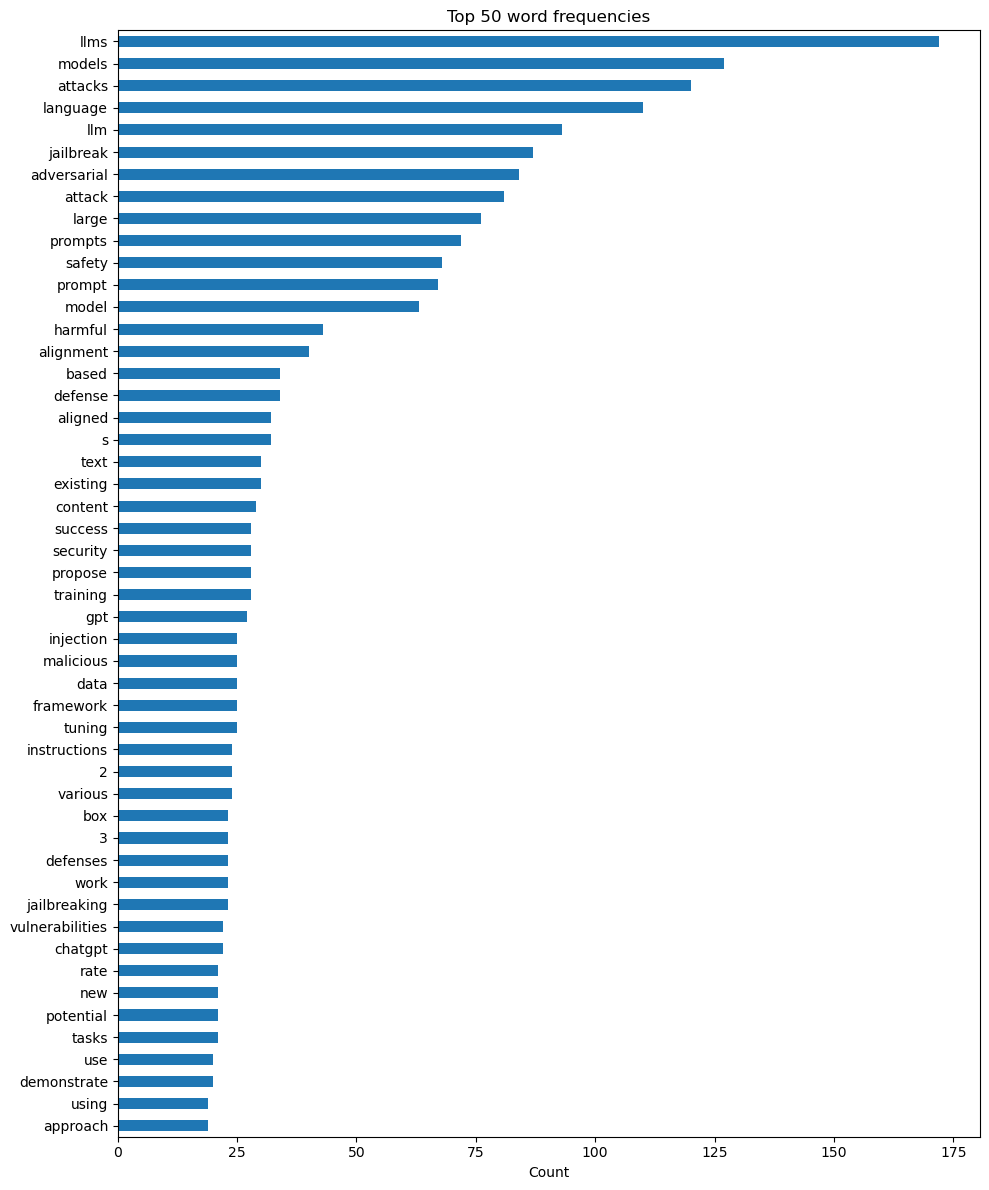

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

top_n = 50
freq_df = pd.DataFrame(Counter(tokens).most_common(top_n), columns=["word", "count"])

ax = freq_df.sort_values("count").plot.barh(x="word", y="count", figsize=(10, 12), legend=False)
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title(f"Top {top_n} word frequencies")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(2, 2))

X = tfidf.fit_transform(df["text"])
feature_names = np.array(tfidf.get_feature_names_out())

scores = np.asarray(X.sum(axis=0)).ravel()
top_idx = scores.argsort()[::-1][:50]
top_terms = list(zip(feature_names[top_idx], scores[top_idx]))

for term, score in top_terms:
    print(term, score)

df_top = pd.DataFrame(top_terms, columns=["term", "score"])
df_top.to_csv("top_tfidf_terms_bigrams.csv", index=False)

language models 1.8965914977404374
large language 1.7503731844462307
prompt injection 1.163026283456132
models llms 1.0804909337208877
jailbreak attacks 0.9919361433506416
black box 0.9179111023607508
safety alignment 0.8959853305971663
adversarial attacks 0.8858606037878114
injection attacks 0.8484664752542015
fine tuning 0.8357396369336699
jailbreak prompts 0.8079200530154911
language model 0.7569364557236784
red teaming 0.6645947658258105
adversarial prompts 0.6482523952232389
success rate 0.611142078696461
state art 0.5928790584815049
open source 0.5780685921561165
attacks defenses 0.5550798834876651
attack success 0.5454912134349245
training data 0.5394815200266299
llm integrated 0.5324538719782657
aligned llms 0.5084494083323042
security privacy 0.5044927094666716
harmful content 0.4724855613245861
adversarial prompt 0.4627850050117899
multi modal 0.42680879394575627
llm self 0.4203687140879917
integrated applications 0.4168157453974476
self defense 0.4163601335231336
backdoor at

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["text"])
feature_names = np.array(tfidf.get_feature_names_out())

scores = np.asarray(X.sum(axis=0)).ravel()
top_idx = scores.argsort()[::-1][:10] # :50
for term, score in zip(feature_names[top_idx], scores[top_idx]):
    print(term, score)


llms 4.432241499847691
attacks 3.665660417486107
jailbreak 3.185429431529707
llm 3.1727018556558764
adversarial 3.1634511362837374
models 3.02506883783241
prompts 2.9284913193808917
prompt 2.822610098088888
language 2.623438520414217
attack 2.541561250788963


In [ ]:
import os
import json

folder = r"D:\OneDrive\Desktop\Personal project\Email_Automation\articles"  # change this
output_path = os.path.join(folder, "merged.json")

all_items = []

for root, dirs, files in os.walk(folder):
    for name in files:
        if not name.lower().endswith(".json"):
            continue
        path = os.path.join(root, name)
        if os.path.abspath(path) == os.path.abspath(output_path):
            continue  
        
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, list):
                all_items.extend(data)
            else:
                all_items.append(data)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(all_items, f, ensure_ascii=False, indent=2)


In [ ]:
import os
import pandas as pd

folder = r"D:\OneDrive\Desktop\Personal project\Email_Automation\articles"  # change this

all_dfs = []

for root, dirs, files in os.walk(folder):
    for name in files:
        if not name.lower().endswith(".json"):
            continue
        path = os.path.join(root, name)
        
        df = pd.read_json(path)  
        df["source_file"] = name  
        all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)
print(merged_df.head())


   total_papers  papers_after_status_filter  matching_results  \
0         78658                       64809              1135   
1         78658                       64809              1135   
2         78658                       64809              1135   
3         78658                       64809              1135   
4         78658                       64809              1135   

                                     filtered_papers            source_file  
0  {'id': 'J9DxFokoRL', 'title': 'Rigid Body Adve...  adversarial 1135.json  
1  {'id': 'kgNkf7YSSM', 'title': 'Robustifying Po...  adversarial 1135.json  
2  {'id': 'article-29418', 'title': 'A Closer Loo...  adversarial 1135.json  
3  {'id': 'article-28365', 'title': 'AGS: Afforda...  adversarial 1135.json  
4  {'id': 'article-30121', 'title': 'Accelerating...  adversarial 1135.json  


In [ ]:
import pandas as pd
import json  

url = r"D:\OneDrive\Desktop\Personal project\Email_Automation\articles\merged.json"
df = pd.read_json(url) 

exploded_df = df['filtered_papers'].explode()

total_ids = len(exploded_df.dropna())
unique_ids = exploded_df.str['id'].dropna().nunique() 

print(f"Total papers: {total_ids}")
print(f"Unique IDs: {unique_ids}")


Total papers: 9396
Unique IDs: 6804


In [ ]:
import pandas as pd
import json

url = r"D:\OneDrive\Desktop\Personal project\Email_Automation\articles\merged.json"
df = pd.read_json(url)

exploded_df = df['filtered_papers'].explode()
sites = exploded_df.str['site'].dropna().tolist()

unique_sites = list(pd.Series(sites).unique())

with open('unique_sites.json', 'w') as f:
    json.dump(unique_sites, f, indent=2)

unique_sites_df = pd.DataFrame({'site': unique_sites})
unique_sites_df.to_csv('unique_sites.txt', index=False, header=False)

print("First 5 unique:", unique_sites[:5])
print(f"Total unique: {len(unique_sites)}")


First 5 unique: ['https://openreview.net/forum?id=J9DxFokoRL', 'https://ojs.aaai.org/index.php/AAAI/article/view/30472', 'https://ojs.aaai.org/index.php/AAAI/article/view/28365', 'https://ojs.aaai.org/index.php/AAAI/article/view/28147', 'https://ojs.aaai.org/index.php/AAAI/article/view/27796']
Total unique: 2875


In [ ]:
import json
from collections import Counter
import pandas as pd  

with open('openview_emails.json', 'r') as f:
    data = json.load(f)

all_emails = []
for pdf_name, emails in data.items():
    all_emails.extend(emails)

total_emails = len(all_emails)
unique_emails = set(all_emails)
num_unique = len(unique_emails)
has_dups = total_emails > num_unique

print(f"Total emails: {total_emails}")
print(f"Unique emails: {num_unique}")
print(f"Has duplicates: {has_dups}")

if has_dups:
    counts = Counter(all_emails)
    duplicates = {email: count for email, count in counts.items() if count > 1}
    print("Duplicates:", duplicates)

df_results = pd.DataFrame({
    'pdf': list(data.keys()),
    'emails': list(data.values())
})
df_results.to_json('duplicate_check.json', indent=2)


Total emails: 1514
Unique emails: 1336
Has duplicates: True
Duplicates: {'permissions@acm.org': 31, 'cxiao34@wisc.edu': 6, 'goosehe@cs.washington.edu': 2, 'yqsong@cse.ust.hk': 5, 'aihuang@tsinghua.edu.cn': 7, 'zx-zhang22@mails.tsinghua.edu.cn': 3, 'diyiy@stanford.edu': 2, 'zhen.xiang.lance@gmail.com': 2, 'yangchao@pjlab.org.cn': 2, 'fwang598@usc.edu': 3, 'shuai.zhao@ntu.edu.sg': 3, 'cm1838@rutgers.edu': 2, 'tianlong@cs.unc.edu': 3, 'yangliu@ntu.edu.sg': 3, 'yi009@e.ntu.edu.sg': 2, 'liyiming.tech@gmail.com': 3, 'john.doe@gmail.com': 7, 'johnlee@gmail.com': 4, 'shaojing@pjlab.org.cn': 4, 'weixu@tsinghua.edu.cn': 2, 'cenchen@dase.ecnu.edu.cn': 3, 'muhchen@ucdavis.edu': 4, 'zhaohai@cs.sjtu.edu.cn': 2, 'dingpeng@smail.nju.edu.cn': 2, 'jun2@student.unimelb.edu.au': 2, 'qinli@ucdavis.edu': 2, 'liudongrui@pjlab.org.cn': 3, 'qiongkai.xu@mq.edu.au': 3, 'zqzeng@scut.edu.cn': 3, 'zxiangaa@uga.edu': 2, 'jingli.phd@hotmail.com': 2, 'tongwu@princeton.edu': 2, 'evan.zx@ant-intl.com': 3, 'lis221@lehigh